In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Define paths
PROCESSED_DATA_DIR = Path('../data/processed')
FIGURES_DIR = Path('../results/figures')

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [2]:
# Load the clean merged data
df = pd.read_csv(PROCESSED_DATA_DIR / 'stroke_merged_clean.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset shape: (5609, 13)

Columns: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke', 'source']


## 1. Thống Kê Mô Tả (Descriptive Statistics)

### 1.1 Biến Số (Numeric Variables)

In [3]:
# Numeric columns statistics
numeric_cols = ['age', 'avg_glucose_level', 'bmi']

print("📈 THỐNG KÊ MÔ TẢ - BIẾN SỐ")
print("=" * 60)
df[numeric_cols].describe().round(2)

📈 THỐNG KÊ MÔ TẢ - BIẾN SỐ


,age,avg_glucose_level,bmi
count,5609.00,5609.00,5316.00
mean,43.05,106.29,28.92
std,22.54,45.44,7.82
min,0.00,50.00,10.30
25%,25.00,77.20,23.58
50%,45.00,92.00,28.10
75%,61.00,114.37,33.10
max,84.00,271.74,97.60


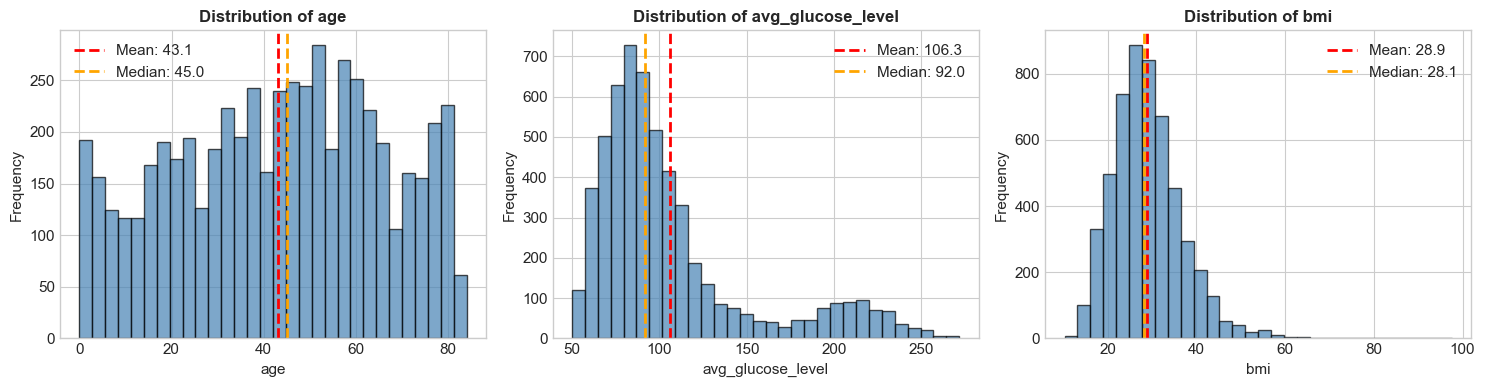

In [4]:
# Histogram for numeric variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {df[col].median():.1f}')
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

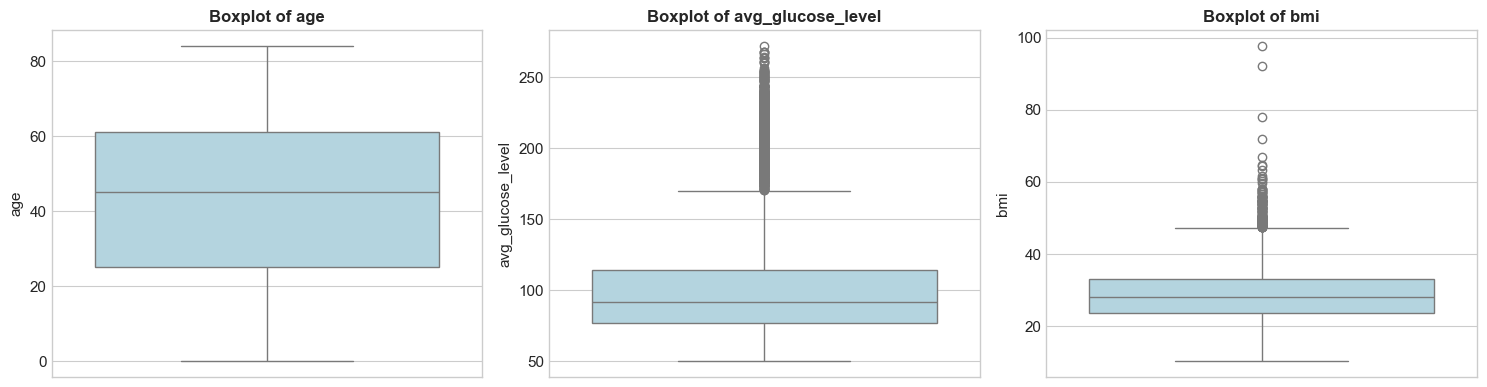

In [5]:
# Boxplot for numeric variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, y=col, ax=ax, color='lightblue')
    ax.set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_numeric_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2 Biến Phân Loại (Categorical Variables)

In [6]:
# Categorical columns
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
binary_cols = ['hypertension', 'heart_disease']

print("📊 PHÂN BỐ - BIẾN PHÂN LOẠI\n")
for col in categorical_cols + binary_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

📊 PHÂN BỐ - BIẾN PHÂN LOẠI


--- gender ---
gender
Female    3293
Male      2316
Name: count, dtype: int64

--- ever_married ---
ever_married
Yes    3672
No     1937
Name: count, dtype: int64

--- work_type ---
work_type
Private          3202
Self-employed     899
children          747
Govt_job          736
Never_worked       25
Name: count, dtype: int64

--- Residence_type ---
Residence_type
Urban    2883
Rural    2726
Name: count, dtype: int64

--- smoking_status ---
smoking_status
never smoked       2079
Unknown            1680
formerly smoked     978
smokes              872
Name: count, dtype: int64

--- hypertension ---
hypertension
0    5072
1     537
Name: count, dtype: int64

--- heart_disease ---
heart_disease
0    5314
1     295
Name: count, dtype: int64


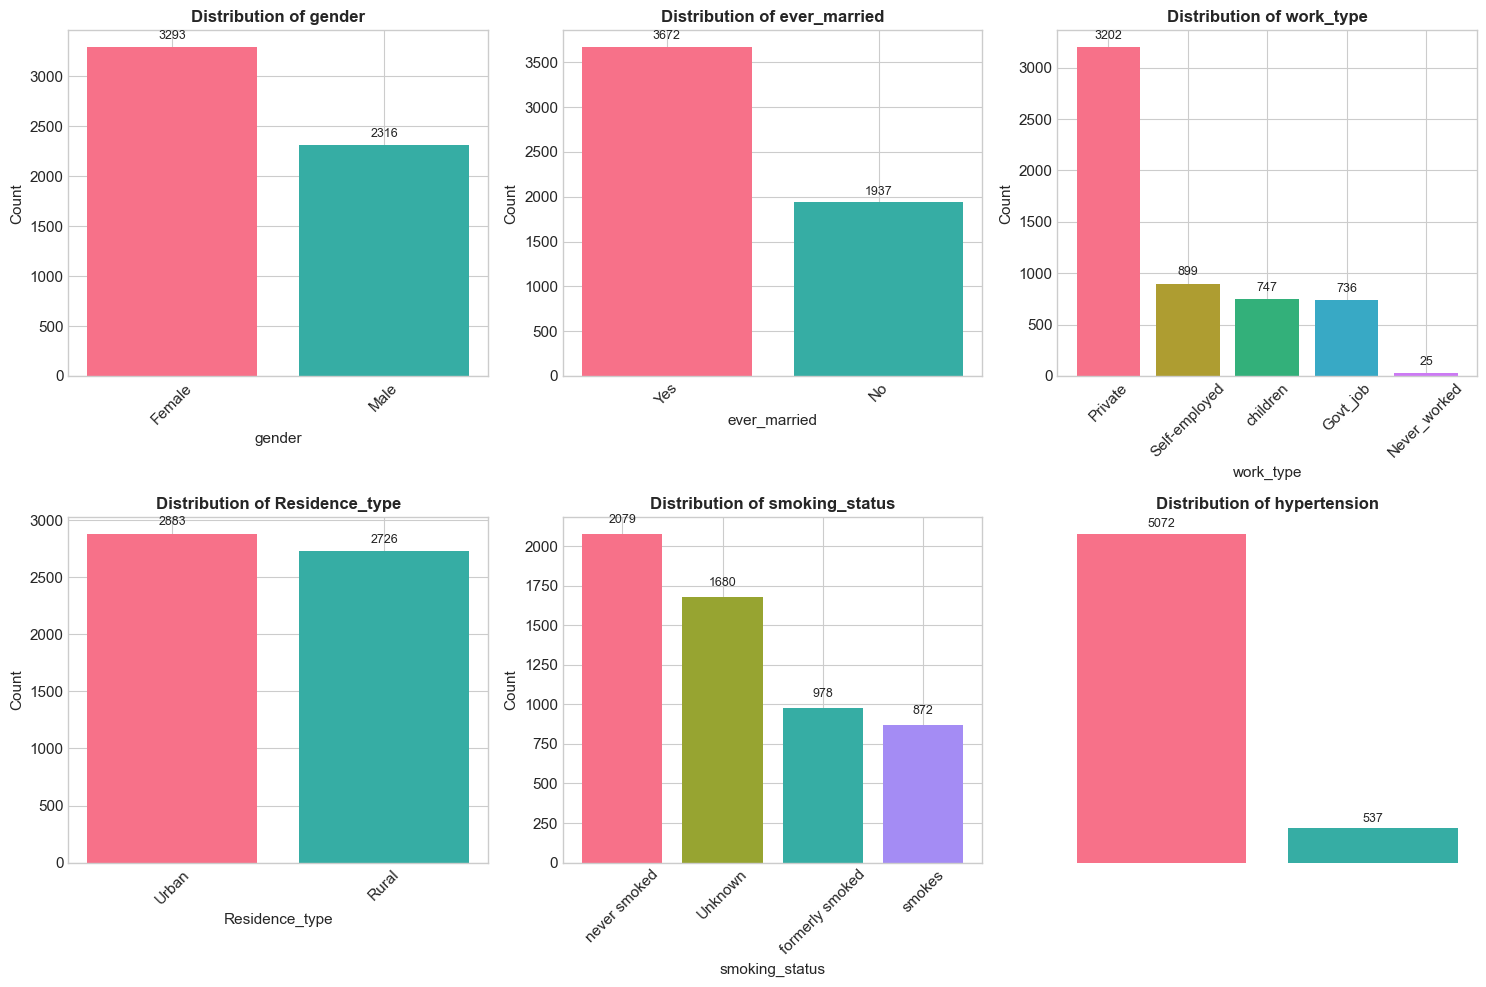

In [7]:
# Bar charts for categorical variables
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols + binary_cols):
    counts = df[col].value_counts()
    bars = ax.bar(counts.index.astype(str), counts.values, color=sns.color_palette('husl', len(counts)))
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                f'{val}', ha='center', va='bottom', fontsize=9)

# Hide the last empty subplot
axes[-1].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Phân Bố Biến Mục Tiêu (Target: Stroke)

### ⚠️ Imbalanced Data Analysis

In [8]:
# Target distribution
stroke_counts = df['stroke'].value_counts()
stroke_pct = df['stroke'].value_counts(normalize=True) * 100

print("🎯 PHÂN BỐ BIẾN MỤC TIÊU (STROKE)")
print("=" * 40)
print(f"{'Stroke':<10} {'Count':<10} {'Percentage':<10}")
print("-" * 30)
for idx in stroke_counts.index:
    label = 'Yes (1)' if idx == 1 else 'No (0)'
    print(f"{label:<10} {stroke_counts[idx]:<10} {stroke_pct[idx]:.2f}%")

print(f"\n⚠️ Imbalance Ratio: 1:{stroke_counts[0]/stroke_counts[1]:.0f}")

🎯 PHÂN BỐ BIẾN MỤC TIÊU (STROKE)
Stroke     Count      Percentage
------------------------------
No (0)     5338       95.17%
Yes (1)    271        4.83%

⚠️ Imbalance Ratio: 1:20


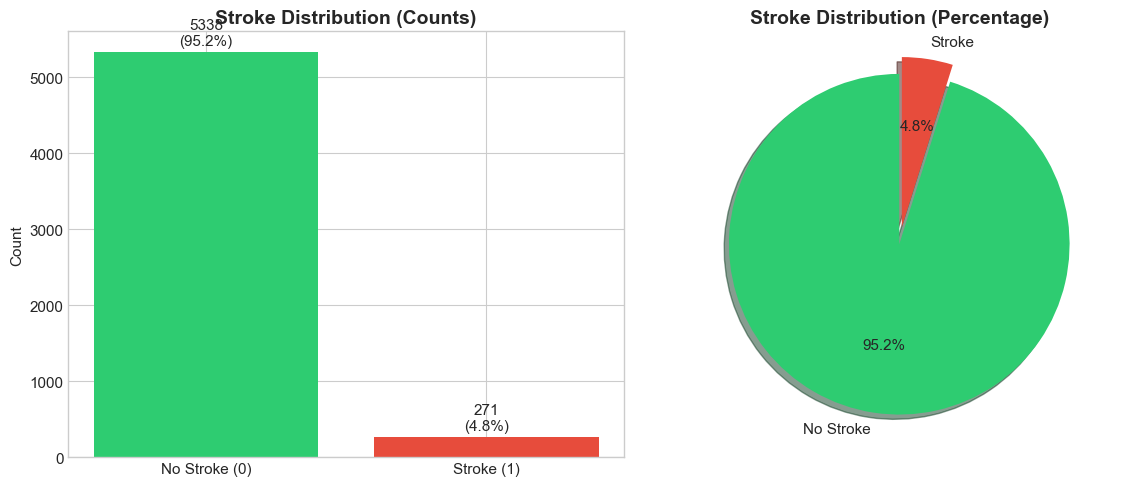


💡 INSIGHT: Dữ liệu rất mất cân bằng - chỉ ~5% có stroke!
   → Cần áp dụng kỹ thuật xử lý imbalanced data (SMOTE, class_weight, ...)


In [9]:
# Visualize target imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['No Stroke (0)', 'Stroke (1)'], stroke_counts.values, color=colors)
axes[0].set_title('Stroke Distribution (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, stroke_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=11)

# Pie chart
axes[1].pie(stroke_counts.values, labels=['No Stroke', 'Stroke'], autopct='%1.1f%%',
            colors=colors, explode=[0, 0.1], shadow=True, startangle=90)
axes[1].set_title('Stroke Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_target_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHT: Dữ liệu rất mất cân bằng - chỉ ~5% có stroke!")
print("   → Cần áp dụng kỹ thuật xử lý imbalanced data (SMOTE, class_weight, ...)")

## 3. Diagnostic Analysis: Stroke vs Non-Stroke

### 3.1 Numeric Variables by Stroke Status

In [10]:
# Statistics by stroke status
print("📊 THỐNG KÊ THEO NHÓM STROKE\n")
df.groupby('stroke')[numeric_cols].agg(['mean', 'median', 'std']).round(2)

📊 THỐNG KÊ THEO NHÓM STROKE



age               avg_glucose_level                   bmi         \
         mean median    std              mean  median    std   mean median   
stroke                                                                       
0       41.80   43.0  22.22            105.00   91.65  44.09  28.85   28.0   
1       67.71   71.0  12.46            131.78  104.86  61.51  30.49   29.7   

              
         std  
stroke        
0       7.87  
1       6.31

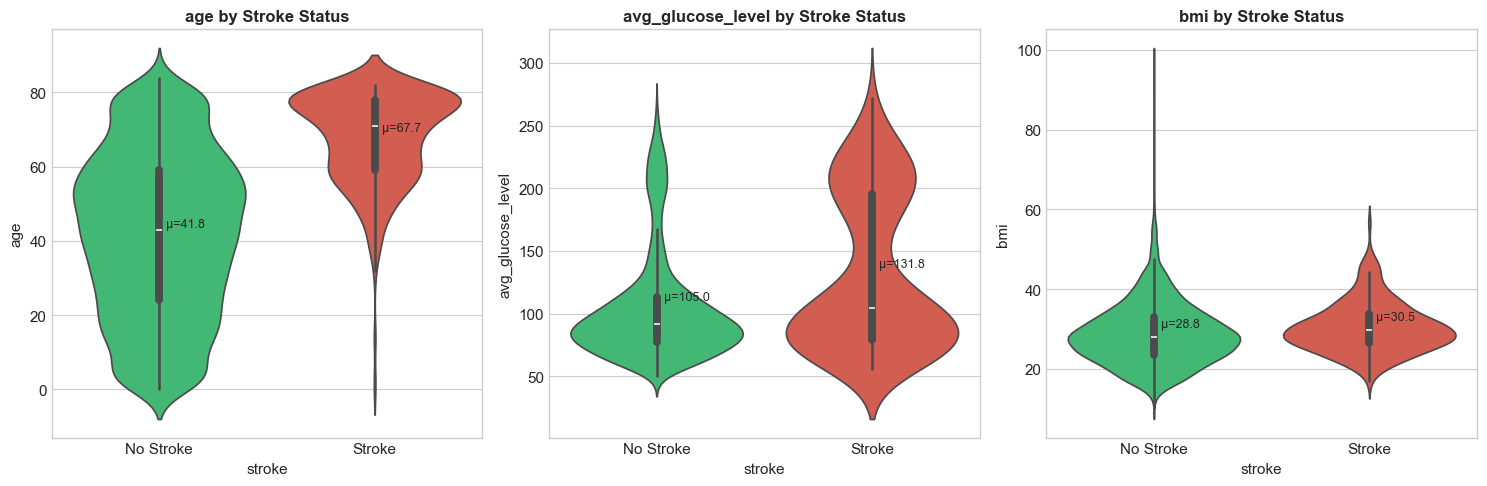


💡 INSIGHTS:
   - Age: Người bị stroke có tuổi trung bình cao hơn đáng kể
   - Glucose: Mức glucose trung bình cao hơn ở nhóm stroke
   - BMI: Khác biệt không rõ ràng


In [11]:
# Violin plots: Numeric variables by stroke
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, numeric_cols):
    sns.violinplot(data=df, x='stroke', y=col, ax=ax, palette=['#2ecc71', '#e74c3c'])
    ax.set_title(f'{col} by Stroke Status', fontsize=12, fontweight='bold')
    ax.set_xticklabels(['No Stroke', 'Stroke'])
    
    # Add mean values
    means = df.groupby('stroke')[col].mean()
    for i, (stroke_val, mean_val) in enumerate(means.items()):
        ax.annotate(f'μ={mean_val:.1f}', xy=(i, mean_val), 
                    xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_numeric_by_stroke.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHTS:")
print("   - Age: Người bị stroke có tuổi trung bình cao hơn đáng kể")
print("   - Glucose: Mức glucose trung bình cao hơn ở nhóm stroke")
print("   - BMI: Khác biệt không rõ ràng")

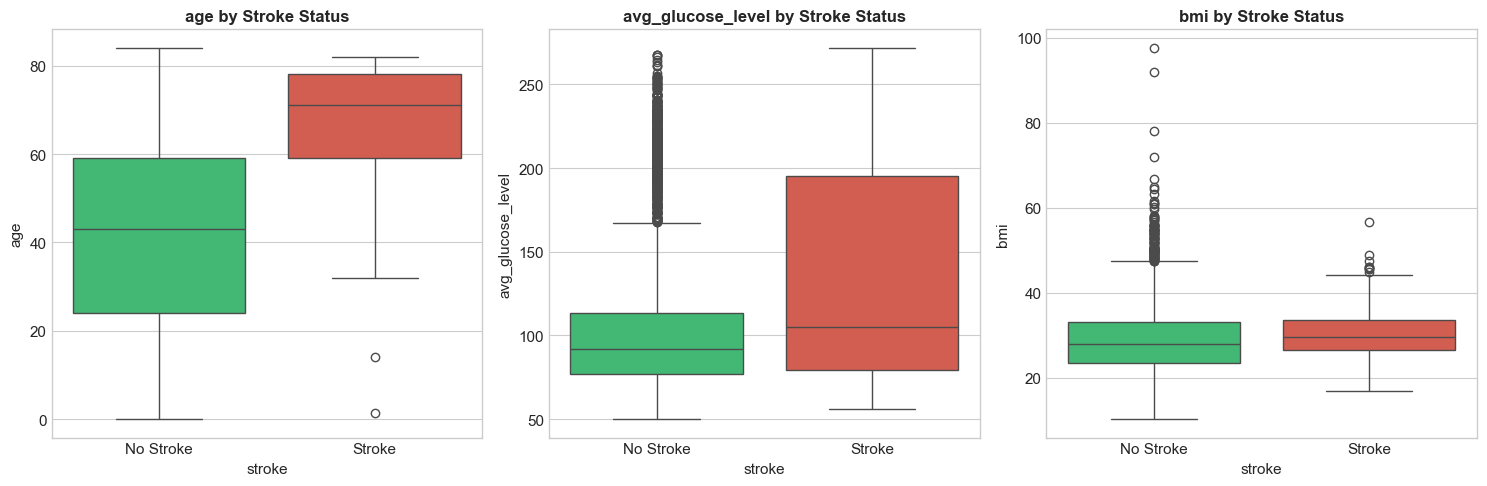

In [12]:
# Boxplots comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x='stroke', y=col, ax=ax, palette=['#2ecc71', '#e74c3c'])
    ax.set_title(f'{col} by Stroke Status', fontsize=12, fontweight='bold')
    ax.set_xticklabels(['No Stroke', 'Stroke'])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_boxplot_by_stroke.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Categorical Variables by Stroke Status

In [13]:
# Stroke rate by categorical variables
print("📊 TỈ LỆ STROKE THEO BIẾN PHÂN LOẠI\n")

for col in categorical_cols + binary_cols:
    print(f"\n--- {col} ---")
    cross_tab = pd.crosstab(df[col], df['stroke'], normalize='index') * 100
    cross_tab.columns = ['No Stroke %', 'Stroke %']
    print(cross_tab.round(2))

📊 TỈ LỆ STROKE THEO BIẾN PHÂN LOẠI


--- gender ---
        No Stroke %  Stroke %
gender                       
Female        95.38      4.62
Male          94.86      5.14

--- ever_married ---
              No Stroke %  Stroke %
ever_married                       
No                  98.40      1.60
Yes                 93.46      6.54

--- work_type ---
               No Stroke %  Stroke %
work_type                           
Govt_job             95.11      4.89
Never_worked        100.00      0.00
Private              94.91      5.09
Self-employed        92.21      7.79
children             99.73      0.27

--- Residence_type ---
                No Stroke %  Stroke %
Residence_type                       
Rural                 95.52      4.48
Urban                 94.83      5.17

--- smoking_status ---
                 No Stroke %  Stroke %
smoking_status                        
Unknown                96.79      3.21
formerly smoked        92.33      7.67
never smoked           95.33

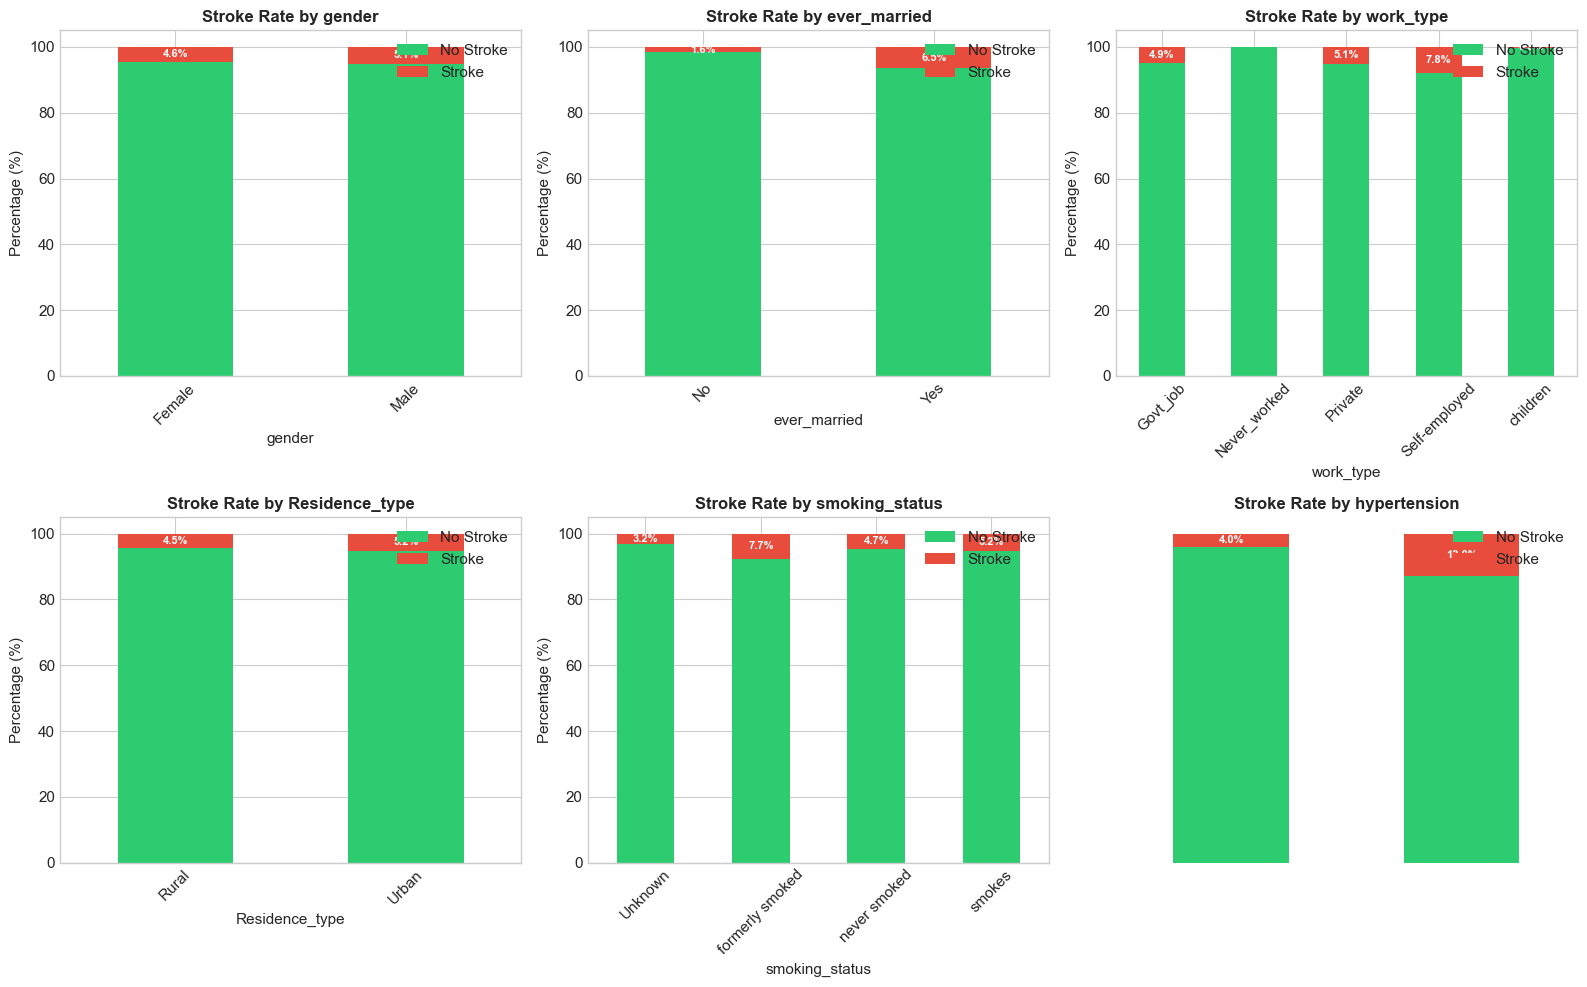


💡 INSIGHTS:
   - Hypertension: Người cao huyết áp có tỉ lệ stroke cao hơn (~2x)
   - Heart Disease: Người bệnh tim có tỉ lệ stroke cao hơn (~3x)
   - Ever Married: Người đã kết hôn có tỉ lệ stroke cao hơn (liên quan tuổi)
   - Smoking: 'formerly smoked' có tỉ lệ stroke cao nhất


In [21]:
# Stacked bar charts for stroke rate by categorical variables
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols + binary_cols):
    # Calculate stroke rate
    cross_tab = pd.crosstab(df[col], df['stroke'], normalize='index') * 100
    
    # Plot
    cross_tab.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'])
    ax.set_title(f'Stroke Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Percentage (%)')
    ax.legend(['No Stroke', 'Stroke'], loc='upper right')
    ax.tick_params(axis='x', rotation=45)
    
    # Add stroke percentage labels
    for i, (idx, row) in enumerate(cross_tab.iterrows()):
        if row[1] > 0:  # stroke percentage
            ax.text(i, 100 - row[1]/2, f'{row[1]:.1f}%', ha='center', va='center', 
                    fontsize=8, color='white', fontweight='bold')

# Hide the last empty subplot
axes[-1].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_stroke_rate_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHTS:")
print("   - Hypertension: Người cao huyết áp có tỉ lệ stroke cao hơn (~2x)")
print("   - Heart Disease: Người bệnh tim có tỉ lệ stroke cao hơn (~3x)")
print("   - Ever Married: Người đã kết hôn có tỉ lệ stroke cao hơn (liên quan tuổi)")
print("   - Smoking: 'formerly smoked' có tỉ lệ stroke cao nhất")

### 3.3 Age Distribution by Stroke

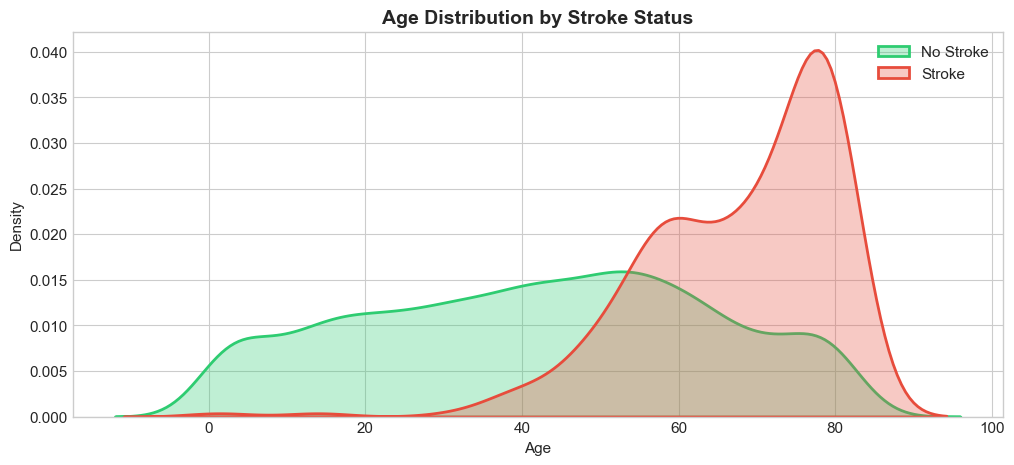


💡 INSIGHT: Stroke tập trung ở nhóm tuổi cao (>60)
   - Tuổi TB nhóm No Stroke: 41.8
   - Tuổi TB nhóm Stroke: 67.7


In [22]:
# Age distribution comparison
fig, ax = plt.subplots(figsize=(12, 5))

# KDE plot
for stroke_val, color, label in [(0, '#2ecc71', 'No Stroke'), (1, '#e74c3c', 'Stroke')]:
    subset = df[df['stroke'] == stroke_val]['age']
    sns.kdeplot(data=subset, ax=ax, color=color, label=label, linewidth=2, fill=True, alpha=0.3)

ax.set_title('Age Distribution by Stroke Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.legend()

plt.savefig(FIGURES_DIR / 'eda_age_distribution_by_stroke.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHT: Stroke tập trung ở nhóm tuổi cao (>60)")
print(f"   - Tuổi TB nhóm No Stroke: {df[df['stroke']==0]['age'].mean():.1f}")
print(f"   - Tuổi TB nhóm Stroke: {df[df['stroke']==1]['age'].mean():.1f}")

## 4. Correlation Analysis

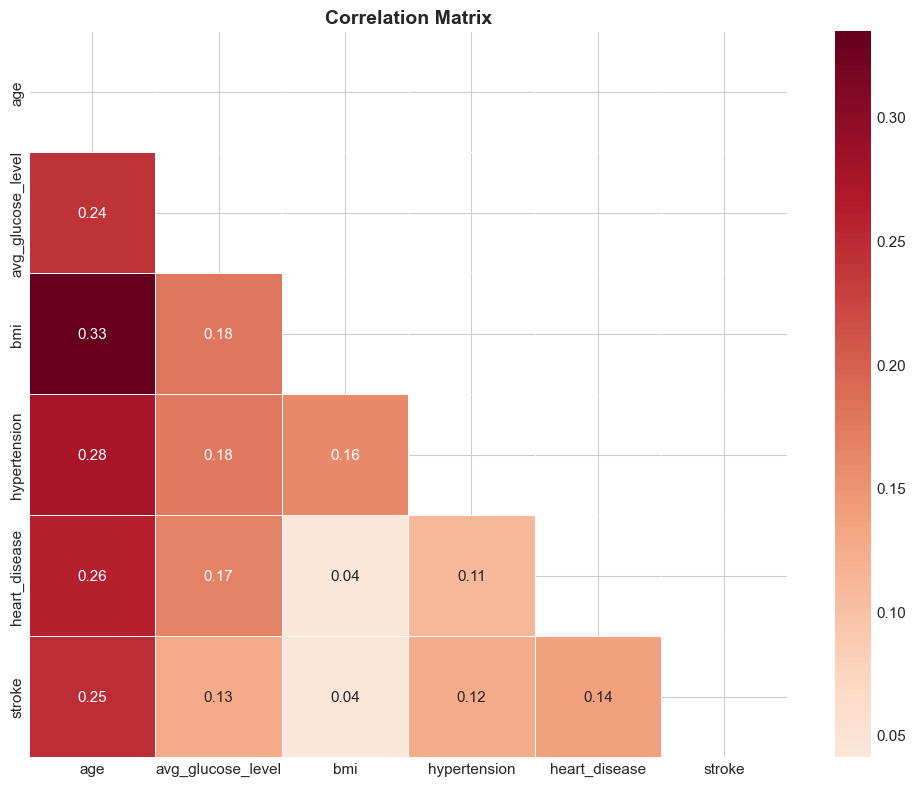


💡 INSIGHTS về Correlation với Stroke:
stroke               1.000000
age                  0.246429
heart_disease        0.136871
avg_glucose_level    0.126398
hypertension         0.124488
bmi                  0.042079
Name: stroke, dtype: float64


In [23]:
# Prepare numeric data for correlation
df_numeric = df[numeric_cols + ['hypertension', 'heart_disease', 'stroke']].copy()

# Correlation matrix
corr_matrix = df_numeric.corr()

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 INSIGHTS về Correlation với Stroke:")
print(corr_matrix['stroke'].sort_values(ascending=False))

## 5. Data by Source

In [17]:
# Check distribution by source
if 'source' in df.columns:
    print("📊 PHÂN BỐ THEO NGUỒN DỮ LIỆU\n")
    
    # Count by source
    print(df['source'].value_counts())
    
    # Stroke rate by source
    print("\n--- Stroke Rate by Source ---")
    stroke_by_source = df.groupby('source')['stroke'].agg(['sum', 'count', 'mean'])
    stroke_by_source.columns = ['Stroke Count', 'Total', 'Stroke Rate']
    stroke_by_source['Stroke Rate'] = (stroke_by_source['Stroke Rate'] * 100).round(2)
    print(stroke_by_source)

📊 PHÂN BỐ THEO NGUỒN DỮ LIỆU

source
kaggle       5109
synthetic     500
Name: count, dtype: int64

--- Stroke Rate by Source ---
           Stroke Count  Total  Stroke Rate
source                                     
kaggle              249   5109         4.87
synthetic            22    500         4.40


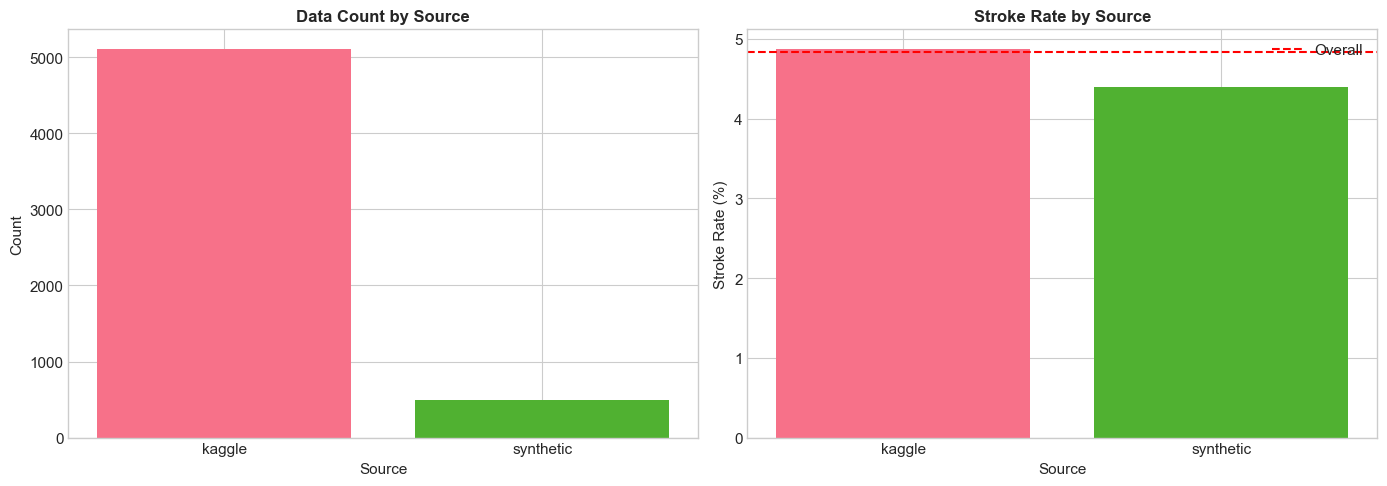

In [18]:
# Visualize by source
if 'source' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Count by source
    source_counts = df['source'].value_counts()
    axes[0].bar(source_counts.index, source_counts.values, color=sns.color_palette('husl', 3))
    axes[0].set_title('Data Count by Source', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Source')
    axes[0].set_ylabel('Count')
    
    # Stroke rate by source
    stroke_rate = df.groupby('source')['stroke'].mean() * 100
    axes[1].bar(stroke_rate.index, stroke_rate.values, color=sns.color_palette('husl', 3))
    axes[1].set_title('Stroke Rate by Source', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Source')
    axes[1].set_ylabel('Stroke Rate (%)')
    axes[1].axhline(df['stroke'].mean() * 100, color='red', linestyle='--', label='Overall')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'eda_by_source.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Key Insights Summary

### 📊 Tổng Kết EDA

#### 1. **Imbalanced Data**
- Tỉ lệ stroke rất thấp (~5%)
- Imbalance ratio khoảng 1:20
- → Cần xử lý bằng SMOTE hoặc class_weight

#### 2. **Risk Factors (Yếu tố nguy cơ)**
- **Age**: Yếu tố quan trọng nhất - tuổi cao → nguy cơ stroke cao
- **Hypertension**: Cao huyết áp tăng nguy cơ ~2x
- **Heart Disease**: Bệnh tim tăng nguy cơ ~3x
- **Glucose**: Mức glucose cao có liên quan đến stroke
- **Smoking**: 'Formerly smoked' có tỉ lệ stroke cao nhất

#### 3. **BMI**
- Có missing data (~3-15%)
- Không có sự khác biệt rõ ràng giữa 2 nhóm

#### 4. **Correlation**
- Age có correlation cao nhất với stroke
- Hypertension và heart_disease cũng có tương quan dương

In [19]:
# Save summary statistics
summary_stats = {
    'total_samples': len(df),
    'stroke_count': int(df['stroke'].sum()),
    'stroke_rate': round(df['stroke'].mean() * 100, 2),
    'imbalance_ratio': round(df['stroke'].value_counts()[0] / df['stroke'].value_counts()[1], 1),
    'missing_bmi_pct': round(df['bmi'].isnull().sum() / len(df) * 100, 2),
    'mean_age_stroke': round(df[df['stroke']==1]['age'].mean(), 1),
    'mean_age_no_stroke': round(df[df['stroke']==0]['age'].mean(), 1),
}

print("📊 SUMMARY STATISTICS")
print("=" * 40)
for key, value in summary_stats.items():
    print(f"{key}: {value}")

# Save to file
import json
with open(PROCESSED_DATA_DIR / 'eda_summary.json', 'w') as f:
    json.dump(summary_stats, f, indent=2)
print("\n✅ Summary saved to data/processed/eda_summary.json")

📊 SUMMARY STATISTICS
total_samples: 5609
stroke_count: 271
stroke_rate: 4.83
imbalance_ratio: 19.7
missing_bmi_pct: 5.22
mean_age_stroke: 67.7
mean_age_no_stroke: 41.8

✅ Summary saved to data/processed/eda_summary.json


In [20]:
print("\n" + "=" * 60)
print("✅ EDA & VISUALIZATION COMPLETE!")
print("=" * 60)
print(f"\n📁 Figures saved to: {FIGURES_DIR}")
print("\nNext: Notebook 04 - Modeling")


✅ EDA & VISUALIZATION COMPLETE!

📁 Figures saved to: ..\results\figures

Next: Notebook 04 - Modeling
